In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Encoding Numerical Features:

- Encoding numerical features refers to the process of representing numerical data in a format suitable for machine learning algorithms.

- Two famous techniques to convert from numerical to categorical
 
1.  Discretization (also called as binning)
2.  Binarization


## 1. Discretization ( also called as binning)

Discretization is the process of transforming continous variables into discrete variables by creating a set of contigous intervals that span the range of the variable's values.Discretization is also called binning, where bin is an alternative name for interval.

Why use Discretization : 

1. To handle Outliers.

2. To improve the value spread

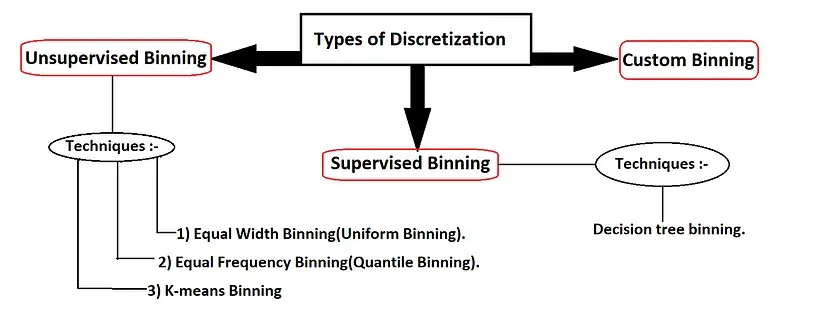
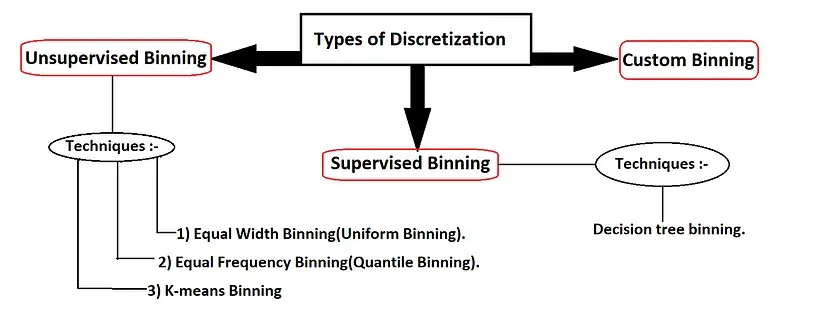

## 1. Unsupervised Binning :


### Titanic data example

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv('/kaggle/input/datasets/shashikalarajesh11/titanic-dataset/Titanic-Dataset.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isna().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df.shape

(714, 3)

In [8]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [9]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [11]:
clf=DecisionTreeClassifier()

In [12]:
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

In [13]:
accuracy_score(y_test,y_pred)

0.6363636363636364

In [14]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

np.float64(0.6275234741784037)

In [15]:
kbin_age=KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')
kbin_fare=KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')

In [16]:
trf=ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [17]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

In [18]:
trf.named_transformers_['first'].n_bins_

array([5])

In [20]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42      , 12.69636862, 27.02765256, 39.35418895, 54.21464646,
              80.        ])                                                   ],
      dtype=object)

In [21]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.        ,  42.42381445, 100.62403884, 186.50018901,
              376.60581786, 512.3292    ])                           ],
      dtype=object)

In [22]:
output=pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [23]:
output['age_labels']=pd.cut(x=X_train['Age'],
                           bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels']=pd.cut(x=X_train['Fare'],
                           bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [24]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
755,0.67,0.0,14.5000,0.0,"(0.42, 12.696]","(0.0, 42.424]"
871,47.00,3.0,52.5542,1.0,"(39.354, 54.215]","(42.424, 100.624]"
343,25.00,1.0,13.0000,0.0,"(12.696, 27.028]","(0.0, 42.424]"
266,16.00,1.0,39.6875,0.0,"(12.696, 27.028]","(0.0, 42.424]"
67,19.00,1.0,8.1583,0.0,"(12.696, 27.028]","(0.0, 42.424]"


In [25]:
clf=DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2=clf.predict(X_test_trf)

In [26]:
accuracy_score(y_test,y_pred2)

0.6223776223776224

In [27]:
X_trf=trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

np.float64(0.6345070422535211)

In [35]:
from sklearn.preprocessing import KBinsDiscretizer

In [36]:
def descretize(bins,strategy):
    kbin_age=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    trf=ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[0])
    ])
    X_trf=trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title('Before')
    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")
    plt.show()

0.6275039123630672


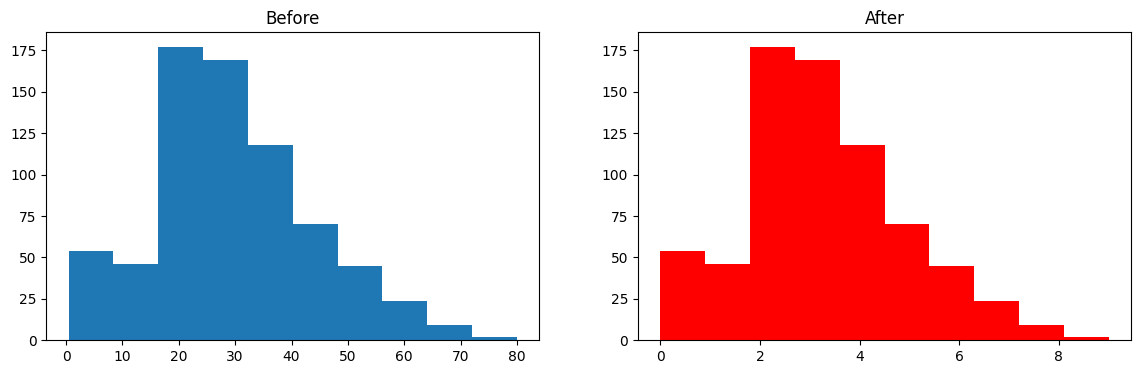

In [39]:
descretize(10,'uniform')